In [1]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
import xgboost as xgb
from scipy.stats import truncnorm

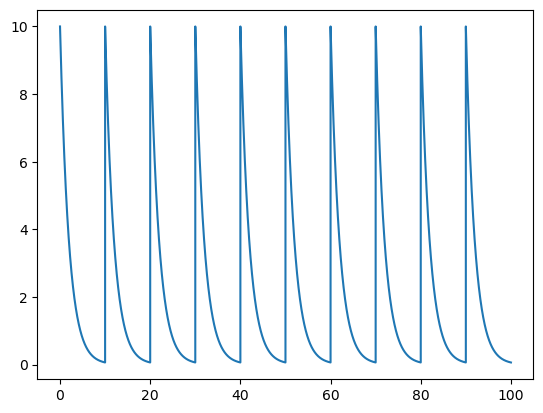

In [2]:
def reward_simulate(state, t,rewards_in_period):
    # print(state)
    phase = t % 20
    if 1 <= state < 2 and phase < 10:
        val = 10 * (0.6 ** phase)
    elif 5<= state < 6  and phase >= 10:
        val = 10 * (0.6 ** (phase-10))
    else:
        val = 0.0
    return float(val)  

def step_at_bounds(state, action, size=7):
    candidate = state + action
    # If candidate goes out of bounds, stay; else move.
    if (candidate < 0).any() or (candidate >= size).any():
        return state.copy()
    return candidate

def simulate_data_count(rewards_in_period,delta,session_duration = 10000,tdim=50, n_sessions=1,seed  = 515):
    """
    Simulate training and testing data with rewards from a given environment.


    Returns:
    - actions, state, ireward, times: np.ndarrays
    """

    np.random.seed(seed)
    actions, states, irewards,times = [], [], [], []
    # state_initial = int(np.random.choice(np.arange(7)))
    state_initial = 1
    for episode in range(n_sessions):
        t = 0
        episode_data = []
        state = state_initial
        for _ in range(session_duration):
            ireward = reward_simulate(state, t, rewards_in_period)
            # print(len(state))
            state_vec = np.array([state]).reshape(1,1)  # shape (1, state_dim)
            time_emb = time_embedding_np(t+1, tdim=tdim).reshape(1,tdim)
            # print(state_vec.shape,time_emb.shape)
            features = np.hstack([state_vec, time_emb])
            ACTIONS = np.array([[-delta],[0],[delta]])
            idx = np.random.randint(len(ACTIONS))
            action = ACTIONS[idx] # up,down, left right
            next_state = step_at_bounds(state, action, size=7)
            # print(next_state)
            episode_data.append((action,features,ireward))
            state = next_state
            t += delta
        for i, (action, features, ireward) in enumerate(episode_data):
            actions.append(action)
            states.append(features)
            irewards.append(ireward)
            times.append(i*delta)

    return (
        np.array(actions),
        np.array(states),
        np.array(irewards),
        np.array(times),
    )

# Time Embedding with absolute time
def time_embedding_np(t, tdim=50):
    freqs = (2 * np.pi) / np.arange(2, tdim + 1, 2)  # shape: (tdim//2,)
    angles = np.outer(t, freqs)
    sin_emb = np.sin(angles)
    cos_emb = np.cos(angles)
    emb = np.concatenate([sin_emb, cos_emb], axis=-1)  # shape: (len(t), tdim)
    if emb.shape[0] == 1:
        return emb[0]  # return (tdim,) for scalar input
    return emb


total_times = 5000
base_reward = 10.0
decay_rate = 0.6
reward_period = 10 

rewards_in_period = []
time_in_periods = []
for period_start in range(0, total_times, reward_period):
    period_end = min(period_start + reward_period, total_times)
    steps_in_period = np.arange(period_start, period_end, 0.001)
    time_in_periods.extend(steps_in_period)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))
plt.plot(time_in_periods[:100000],rewards_in_period[:100000])

In [3]:
def get_candidates(state,t,delta):
    next_state = [state-delta, state, state+delta]
    if next_state[0] < 0 :
        return [state+delta, 0]
    elif next_state[-1] > 7:
        return [state-delta, state]
    else:
        return next_state

def enumerate_paths_cont(x0, t_initial = 0, t_prime=20,delta= 0.001):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr,t,delta):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_initial+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

In [4]:
def get_candidates(state, t, delta):
    next_state = [state - delta, state, state + delta]
    if next_state[0] < 0:
        return [state + delta, 0]
    elif next_state[-1] > 7:
        return [state - delta, state]
    else:
        return next_state

def contains_close(lst, x, atol=1e-12):
    for y in lst:
        if np.isclose(y, x, atol=atol):
            return True
    return False

def get_predecessors(state, t, delta, low=0.0, high=7.0, atol=1e-12):
    # Candidate predecessors (inverse of +/-delta,0 moves), then filter by forward legality
    # prev in [0,7] and state \in get_candidates(prev, t, delta)
    candidates = [state + delta, state, state - delta]
    preds = []
    for prev in candidates:
        if prev < low - atol or prev > high + atol:
            continue
        # Only accept prev if forward from prev can produce `state` (respecting your boundary behavior)
        forward_nexts = get_candidates(prev, t, delta)
        if contains_close(forward_nexts, state, atol=atol):
            preds.append(prev)
    #in case boundaries produce duplicates
    # Use rounding to the grid defined by delta to stabilize
    if preds:
        # round to nearest grid point on the delta lattice
        rpreds = []
        for p in preds:
            # snap to grid to avoid 1e-16 drift
            # snapped = np.clip(round((p - low) / delta) * delta + low, low, high)
            if not contains_close(rpreds, p, atol=atol):
                rpreds.append(p)
        preds = rpreds
    return preds

def enumerate_paths_cont_backward(x0, xT, t_initial=0, t_prime=20, delta=0.001, atol=1e-12,filter = False):
    """
    Build all paths length t_prime that end at xT (terminal), then reverse them and
    keep only those that start at x0 (initial). Output rows go from t=t_initial..t_initial+t_prime.
    """
    # Build backward: layers are times t = t_initial+t_prime-1, ..., t_initial
    paths_back = [[xT]]  # each path grows backward: [..., s_{t-1}, s_t==xT]
    for k in range(t_prime):
        t = t_initial + (t_prime - 1 - k)  # backward step's corresponding forward-time index
        new_paths = []
        for path in paths_back:
            curr = path[0]  # current layer's (forward) "next" state at time t+1
            preds = get_predecessors(curr, t, delta, atol=atol)
            for prev in preds:
                new_paths.append([prev] + path)
        paths_back = new_paths

    # Now each path is [s_0, s_1, ..., s_tprime] but *not* guaranteed to start at x0
    # Filter: keep only those where s_0 == x0 (within tolerance)
    if filter: 
        filtered = []
        for p in paths_back:
            if np.isclose(p[0], x0, atol=atol) and np.isclose(p[-1], xT, atol=atol):
                # (Optional) snap all states to the delta grid to tidy floats
                # p_snapped = [round((s - 0.0) / delta) * delta for s in p]
                # # clamp to [0,7] just in case of rounding wobble
                # p_snapped = [float(np.clip(s, 0.0, 7.0)) for s in p_snapped]
                filtered.append(p)
    else:
        filtered = []
        for p in paths_back:
            filtered.append(p)
    # Convert to DataFrame: columns t=t_initial..t_initial+t_prime
    cols = [f"t={t_initial + delta*i}" for i in range(t_prime + 1)]
    df = pd.DataFrame(filtered, columns=cols)
    return df


In [31]:
gamma = 0.90
T = 30000
delta = 0.2
n= int(T/delta)
print(n)
# seed = np.random.choice(np.arange(0,100),size = 1)
actions, states, irewards, times = simulate_data_count(rewards_in_period,delta,
                                                       session_duration = 500000,tdim=50, 
                                                       n_sessions=1,seed = 515)

prewards = make_weighted_target(irewards, gamma,T = n,normalization = False)
X_train_oh = states[:n,0,:]
# X_train_oh = np.hstack([position_encoder(states[:n,0,0], type="onehot"), states[:n,0,1:]])
print(X_train_oh.shape)
Y_train_action = irewards[:n]
Y_train_value = prewards[:n]

rf_value = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact", 
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=1, colsample_bytree=0.8,
    n_estimators=2000, eval_metric="rmse")
rf_value.fit(X_train_oh, Y_train_value)

rf_action = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact", 
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=1, colsample_bytree=0.8,
    n_estimators=2000, eval_metric="rmse")
rf_action.fit(X_train_oh, Y_train_action)


150000
(150000, 51)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [32]:
delta = 0.2
step_prime = 14
step_prime_value1 = 13
step_prime_value2 = step_prime - step_prime_value1
t_prime = step_prime * delta
T = 3000+20
DELTA_T = 20
k = 1
# current_state = round(states[T,0,0],2)
current_state = 2.7
print(T,current_state)
future_states = [current_state]
for delta_t in np.arange(0,DELTA_T,delta):
    terminal_state_cands = np.arange(current_state-step_prime*delta,current_state+step_prime*delta,delta).reshape(-1,1)
    terminal_state_cands = np.clip(terminal_state_cands, 0, 7, out=terminal_state_cands)
    curr_time = T+delta_t+1+t_prime
    # print(curr_time-1)
    # print(min(terminal_state_cands),max(terminal_state_cands))
    time_emb = time_embedding_np(np.ones(terminal_state_cands.shape[0])*curr_time, tdim=50)
    features = np.hstack([terminal_state_cands,time_emb])
    score_value = rf_value.predict(features)
    score_action = rf_action.predict(features)
    score = score_action+score_value
    bext_idx_value = np.argmax(score)
    best_at_terminal = terminal_state_cands[bext_idx_value].item()
    print(curr_time,best_at_terminal)
    df_all_paths = enumerate_paths_cont_backward(x0=current_state,xT = best_at_terminal, t_initial = T+delta_t+step_prime_value1*delta,t_prime = step_prime_value2,delta = delta,filter = False)
    print(df_all_paths.shape)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  step_prime_value2+1))

    for i_idx in np.arange(step_prime_value1,step_prime+1,1):
        i_idx -= step_prime_value1
        next_state = np.array(df_all_paths.iloc[:,i_idx]).reshape(-1,1)
        curr_time = T+delta_t+i_idx*delta+1
        time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50).reshape(-1,50)
        features = np.hstack([next_state,time_emb])
        # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
        # np.hstack([next_state,time_emb])
        irewards_pred[:,i_idx] = rf_action.predict(features)
    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+idx*delta}" for idx in np.arange(step_prime_value1,step_prime+1,1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    next_state = np.array(df_all_paths.iloc[:,-1]).reshape(-1,1)
    curr_time = T+1+t_prime
    time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50).reshape(-1,50)
    # print(next_state.shape,time_emb.shape)
    features = np.hstack([next_state,time_emb])
    # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
    # np.hstack([next_state,time_emb])
    prewards_pred = rf_value.predict(features)
    df_ireward[f"preward"] = prewards_pred
    rewards_matrix = df_ireward.iloc[:, 1:].values
    discounts = gamma ** np.arange(0, step_prime_value2+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)

    part = np.argpartition(total_discounted, -k)[-k:]          # k largest, unsorted
    topk_idx = part[np.argsort(-total_discounted[part])]       # sort those k
    prev_states = df_all_paths.iloc[topk_idx, 0].round(3).unique().tolist()
    # prov_state_bound = np.clip(round(current_state+step_prime_value*delta,3), 0, 7)
    # prev_states.append(3) ## Make sure there is no huge gap
    print(prev_states)
    
    paths_list = []
    for pre_state in prev_states:
        df_all_paths_1 = enumerate_paths_cont_backward(x0=current_state,xT = pre_state, t_initial = T+delta_t,t_prime = step_prime_value1,delta = delta,filter = True)
        df_all_paths_2 = enumerate_paths_cont_backward(x0=pre_state,xT = best_at_terminal, t_initial = T+delta_t+step_prime_value1*delta,t_prime = step_prime_value2,delta = delta,filter = True)
        df_all_paths_1_arr = np.array(df_all_paths_1)
        df_all_paths_2_arr =np.array(df_all_paths_2)[:,1:]
        # print(df_all_paths_2_arr.shape)
        df_all_paths_1_rep = np.repeat(df_all_paths_1_arr, df_all_paths_2_arr.shape[0], axis=0)
        df_all_paths_2_tile = np.tile(df_all_paths_2_arr, (df_all_paths_1_arr.shape[0], 1))     
        df_all_paths_arr = np.hstack([df_all_paths_1_rep,df_all_paths_2_tile])
        print(df_all_paths_1_arr.shape,df_all_paths_2_arr.shape)
        df_all_paths = pd.DataFrame(df_all_paths_arr, columns=list(df_all_paths_1.columns) + list(df_all_paths_2.columns[1:]))
        # print(df_all_paths.shape)
        paths_list.append(df_all_paths)
    DF_ALL_PATHS = pd.concat(paths_list, ignore_index=True, copy=False)
    DF_ALL_PATHS = DF_ALL_PATHS.drop_duplicates(ignore_index=True)
    print(DF_ALL_PATHS.shape)
    if DF_ALL_PATHS.shape[0] < 1:
        DF_ALL_PATHS = enumerate_paths_cont(x0=current_state, t_initial = T+delta_t,t_prime = step_prime_value1,delta = delta)

    # else: 
    n_paths = DF_ALL_PATHS.shape[0]
    step_prime_infr = DF_ALL_PATHS.shape[1]-1
    irewards_pred = np.zeros((n_paths, step_prime_infr+1))
    
    for i_idx in np.arange(0,step_prime_infr+1,1):
        next_state = np.array(DF_ALL_PATHS.iloc[:,i_idx]).reshape(-1,1)
        curr_time = T+delta_t+i_idx*delta+1
        time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50).reshape(-1,50)
        features = np.hstack([next_state,time_emb])
        # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
        # np.hstack([next_state,time_emb])
        irewards_pred[:,i_idx] = rf_action.predict(features)
    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+idx*delta}" for idx in np.arange(0,step_prime_infr+1,1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    next_state = np.array(DF_ALL_PATHS.iloc[:,-1]).reshape(-1,1)
    curr_time = T+1+step_prime_infr * delta
    time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50).reshape(-1,50)
    # print(next_state.shape,time_emb.shape)
    features = np.hstack([next_state,time_emb])
    # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
    # np.hstack([next_state,time_emb])
    prewards_pred = rf_value.predict(features)
    df_ireward[f"preward"] = prewards_pred
    rewards_matrix = df_ireward.iloc[:, 1:].values
    discounts = gamma ** np.arange(0, step_prime_infr+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    bext_idx = np.argmax(total_discounted)
    next_state = round(DF_ALL_PATHS.iloc[bext_idx,1].item(),3)
    future_states.append(next_state)
    current_state = next_state
    print(T+delta_t+delta,current_state)


3020 2.7
3023.8 1.5
(3, 2)
[1.3]
(12727, 14) (1, 1)
(12727, 15)
3020.2 2.5
3024.0 1.4999999999999998
(3, 2)
[1.3]
(27742, 14) (1, 1)
(27742, 15)
3020.3999999999996 2.3
3024.2000000000003 1.4999999999999996
(3, 2)
[1.3]
(52624, 14) (1, 1)
(52624, 15)
3020.6 2.1
3024.4 1.4999999999999993
(3, 2)
[1.3]
(87802, 14) (1, 1)
(87802, 15)
3020.7999999999997 1.9
3024.6000000000004 1.4999999999999991
(3, 2)
[1.3]
(129844, 14) (1, 1)
(129844, 15)
3021.0 1.9
3024.8 1.4999999999999991
(3, 2)
[1.3]
(129844, 14) (1, 1)
(129844, 15)
3021.2 1.9
3025.0 1.4999999999999991
(3, 2)
[1.3]
(129844, 14) (1, 1)
(129844, 15)
3021.3999999999996 1.9
3025.2000000000003 1.4999999999999991
(3, 2)
[1.3]
(129844, 14) (1, 1)
(129844, 15)
3021.6 1.9
3025.4 1.4999999999999991
(3, 2)
[1.3]
(129844, 14) (1, 1)
(129844, 15)
3021.7999999999997 1.9
3025.6000000000004 1.4999999999999991
(3, 2)
[1.3]
(129844, 14) (1, 1)
(129844, 15)
3022.0 1.9
3025.8 1.4999999999999991
(3, 2)
[1.3]
(129844, 14) (1, 1)
(129844, 15)
3022.2 1.9
3026.

KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (135,) and (11,)

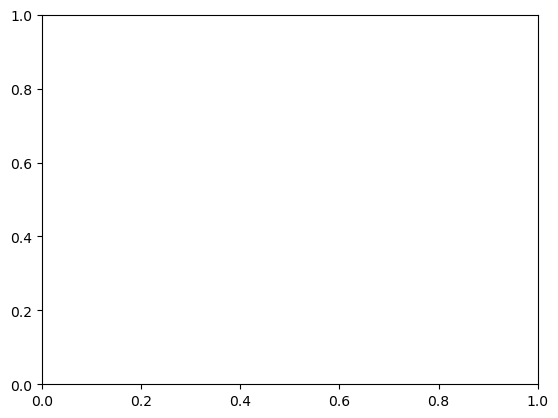

In [27]:
plt.plot(np.arange(T,T+DELTA_T+delta,delta),future_states,label = 'sim')
plt.xticks(np.arange(T,T+DELTA_T+10,10))
plt.fill_between(np.arange(3030,3038,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2,label = 'oracle')
plt.fill_between(np.arange(3050,3058,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2)
# plt.fill_between(np.arange(3070,3078,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2)
plt.fill_between(np.arange(3020,3028,1),np.ones(8)*1,np.ones(8)*2,color = 'red',alpha = 0.2)
plt.fill_between(np.arange(3040,3048,1),np.ones(8)*1,np.ones(8)*2,color = 'red',alpha = 0.2)
# plt.fill_between(np.arange(3060,3068,1),np.ones(8)*1,np.ones(8)*2,color = 'red',alpha = 0.2)
plt.hlines(y = 6, xmin = 3030, xmax = 3037,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 5, xmin = 3030, xmax = 3037,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 6, xmin = 3050, xmax = 3057,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 5, xmin = 3050, xmax = 3057,color = 'r',linestyles= '--',alpha = 0.5)
# plt.hlines(y = 5, xmin = 3070, xmax = 3077,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 1, xmin = 3020, xmax = 3027,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 2, xmin = 3020, xmax = 3027,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 1, xmin = 3040, xmax = 3047,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 2, xmin = 3040, xmax = 3047,color = 'r',linestyles= '--',alpha = 0.5)
# plt.hlines(y = 2, xmin = 3060, xmax = 3067,color = 'r',linestyles= '--',alpha = 0.5)
plt.yticks([0,1,2,3,4,5,6,7])
plt.xlabel('Absolute Time')
plt.ylabel('State')
plt.title('\delta_t = 0.3, lookahead 13 steps (approximation (greedy 1 steps))')
plt.legend()

In [75]:
irewards_pred.shape

(243, 6)